In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

class Markov:
    def __init__(self,bCPP=False):
        self.bCPP = bCPP
        self.iNrStates = None
        self.iMaxTime  = None    
        self.dPij = []
        self.dPre = []
        self.dPost= []
        self.dv   = []
        self.dDK  = []
        self.dCF  = []
        self.bCalculated = False
        self.bCFCalculated = False
        self.iStart = None
        self.iStop  = None
        self.iNrTimesPerPeriod = 1.
        self.bRecalculateTime = False
        self.psymM = None
        self.rng = np.random.default_rng()
    
    def vDefineModel(self,iNrStates,iMaxTime=1200):
        self.iNrStates = iNrStates
        self.iMaxTime = iMaxTime
        #print("..",self.iNrStates,self.iMaxTime)
        try:
            import markovlv as mlv
            if self.bCPP:
                print("CPP: success")
                self.psymM = mlv.MARKOVLV(self.iMaxTime,self.iMaxTime,1)
                self.psymM.vSetNrStates(iNrStates)
                return()
        except:
            print("Falling Back")
        for i in range(iMaxTime):
                tempPij = np.zeros([iNrStates,iNrStates])
                tempPost = np.zeros([iNrStates,iNrStates])
                tempPre = np.zeros([iNrStates])
                tempDK = np.zeros([iNrStates])
                tempCF = np.zeros([iNrStates])
                self.dPij.append(tempPij)
                self.dPost.append(tempPost)
                self.dPre.append(tempPre)
                self.dDK.append(tempDK)
                self.dCF.append(tempCF)         
        tempv = np.zeros([iMaxTime])
        self.dv=tempv
    
    def vSetDiscount(self,fIRate):
        vTemp = 1./(1.+fIRate)
        #print("Discount %.4f"%(vTemp))
        #print (self.iMaxTime, len(self.dv))
        for i in range(self.iMaxTime):
            if self.psymM:
                for j in range(self.iNrStates):
                    self.psymM.dSetDisc(i, j, j, vTemp)
            else:
                self.dv[i] = vTemp
        self.bCalculated = False
        self.bCFCalculated = False
    
    def vSetPij(self,t,i,j,fValue):
        if self.bRecalculateTime: 
            t *= self.iNrTimesPerPeriod
        if self.psymM:
            self.psymM.dSetPij(t,i,j,fValue)
        else:
            self.dPij[t][i,j] = fValue
        self.bCalculated = False
        self.bCFCalculated = False

    def vGetPij(self,t,i,j):
        if self.bRecalculateTime: 
            t *= self.iNrTimesPerPeriod
        if self.psymM:
            self.psymM.vSetGetData(True)
            dValue = self.psymM.dSetPij(t,i,j,0)
            self.psymM.vSetGetData(False)
        else:
            dValue =self.dPij[t][i,j]
        print("P_(%d,%d)(%d) =%10.6e"%(i,j,t,dValue))

    def dGetPij(self,t,i,j):
        if self.bRecalculateTime: 
            t *= self.iNrTimesPerPeriod
        if self.psymM:
            self.psymM.vSetGetData(True)
            dValue = self.psymM.dSetPij(t,i,j,0)
            self.psymM.vSetGetData(False)
        else:
            dValue =self.dPij[t][i,j]
        return(dValue)
    
    def vSetPre(self,t,i,j,fValue):
        if self.bRecalculateTime: 
            t *= self.iNrTimesPerPeriod
        if self.psymM:
            self.psymM.dSetPre(t,i,j,fValue)
        else:
            self.dPre[t][i] = fValue
        self.bCalculated = False
        self.bCFCalculated = False
    
    def vSetPost(self,t,i,j,fValue):
        if self.bRecalculateTime: 
            t *= self.iNrTimesPerPeriod
        if self.psymM:
            self.psymM.dSetPost(t,i,j,fValue)
        else:
            self.dPost[t][i,j] = fValue
        self.bCalculated = False
        self.bCFCalculated = False
    
    def pymBlowMeUp(self,iNrTimesPerPeriod,DefaultStateMapper = dict()):
        psymM = Markov()
        psymM.vDefineModel(self.iNrStates,iMaxTime=self.iMaxTime*iNrTimesPerPeriod)
        psymM.iNrTimesPerPeriod = iNrTimesPerPeriod
        psymM.bRecalculateTime = False
        self.vDoBlowUpStates(psymM,DefaultStateMapper) #To be done ie adjustment of v, P_ij, Pre and Post
        return(psym)
    
    def vDoBlowUpStates(self,psymM,DefaultStateMapper):
        for i in range(self.iNrStates):
            if i not in DefaultStateMapper.keys():
                print("Use %d to itself as default mapper"%(i))
                DefaultStateMapper[i] = i
        fIRate = 1./self.dv[0] - 1.
        psymM.vSetDiscount(fIRate)
        for t in range(self.iMaxTime):
            t0 = self.iMaxTime *self.iNrTimesPerPeriod
            t1 = t0 + self.iNrTimesPerPeriod
            for i in range(self.iNrStates):
                x=[t0*1,t1*1]
                y=[self.dPre[t][i],self.dPost[t][i,i]]
                newval = np.interp(list(range(t0,t1+1))*1., x, y)
                dPDefault  = 1.
                PTemp = np.zeros(self.iNrStates)
                for l in range(self.iNrStates):
                    if l == DefaultStateMapper[i]: continue
                    dTemp = self.dPij[t][i,l] / self.iNrTimesPerPeriod
                    dPDefault  -= dTemp
                    PTemp[l] = dTemp
                PTemp[DefaultStateMapper[i]] = PTemp[l]  
                for k in range(t1-t0):
                    psymM.vSetPre(t0+k,i,i,newval[k])
                    psymM.vSetPij(t0+k,i,l,PTemp[l])
                    for l in range(self.iNrStates):
                        if i == l: continue
                        psymM.vSetPost(t0+k,i,l,self.dPost[t][i,l])
                psymM.vSetPost(t1-1,i,i,newval[-1])
                
    def doCalculateDK(self,iStart,iStop,iAge,iState):
        if self.bRecalculateTime: 
            iAge *= self.iNrTimesPerPeriod
            iStart *= self.iNrTimesPerPeriod
            iStop *= self.iNrTimesPerPeriod
        self.iStop = iStop
        self.iStart = iStart
        self.bCalculated = True
        for i in range(self.iMaxTime):
            self.dDK[i] *= 0.
        
        for i in range(self.iStart-1, self.iStop-1,-1):
            #print("Calc Time", i)
            for j in range(self.iNrStates):
                self.dDK[i][j] = self.dPre[i][j]
                for k in range(self.iNrStates):
                    self.dDK[i][j] += self.dv[i]*self.dPij[i][j,k]*(self.dPost[i][j,k]+self.dDK[i+1][k])
    
    def doCalculateCF(self,iStart,iStop,iAge,iState,bTrace=False):
        if self.bRecalculateTime: 
            iAge *= self.iNrTimesPerPeriod
            iStart *= self.iNrTimesPerPeriod
            iStop *= self.iNrTimesPerPeriod
        self.iStop = iStop
        self.iStart = iStart
        self.bCFCalculated = True
        for i in range(self.iMaxTime):
            self.dCF[i] *= 0.
        
        CurrentP = np.asmatrix(np.identity(self.iNrStates))
        if bTrace:
            print("----- ----- ----- ----- ")
        for i in range(self.iStop, self.iStart):
            if bTrace:
                print("----- ----- ----- ----- ")
                print(" Time ", i)
                print("CF BoP", self.dCF[i])
            for k in range(self.iNrStates):
                for l in range(self.iNrStates):
                    self.dCF[i][k] += CurrentP[k,l] * self.dPre[i][l]
            if bTrace:
                print("CF BoP after Pre", self.dCF[i])
            NextP = np.asmatrix(self.dPij[i])
            if bTrace:
                print("+++++ +++++ +++++ ")
                print("CurrentP\n", CurrentP) 
                print("+++++ +++++ +++++ ")
                print("Next P\n", NextP) 
                print("+++++ +++++ +++++ ")
                
            for k in range(self.iNrStates):
                for l in range(self.iNrStates):
                    for m in range(self.iNrStates):
                        self.dCF[i+1][k] += CurrentP[k,l] * NextP[l,m] * self.dPost[i][l,m]
            if bTrace:
                print("CF EoP t", self.dCF[i])
                print("CF EoP t+1", self.dCF[i+1])
            
            CurrentP = CurrentP * NextP
            if bTrace:
                print("+++++ +++++ +++++ ")
                print("CurrentP EoP\n", CurrentP) 
                print("+++++ +++++ +++++ ")
    
    def dGetDK(self,iStart,iStop,iAge,iState):       
        if self.bRecalculateTime: 
            iAge *= self.iNrTimesPerPeriod
            iStart *= self.iNrTimesPerPeriod
            iStop *= self.iNrTimesPerPeriod
        if self.psymM:
            self.psymM.vSetStartTime(iStart)
            self.psymM.vSetStopTime(iStop)
            return(self.psymM.dGetDK(iAge, iState,1))
        if (iStart != self.iStart or iStop != self.iStop or not(self.bCalculated)):
            self.doCalculateDK(iStart,iStop,iAge,iState)
        return(self.dDK[iAge][iState])

    def dGetCF(self,iStart,iStop,iAge,iState):
        if self.bRecalculateTime: 
            iAge *= self.iNrTimesPerPeriod
            iStart *= self.iNrTimesPerPeriod
            iStop *= self.iNrTimesPerPeriod
        if self.psymM:
            self.psymM.vSetStartTime(iStart)
            self.psymM.vSetStopTime(iStop)
            dT = 0
            for j in range(self.iNrStates):
                dT+=self.psymM.dGetCF(iAge, iState, j)
            return(dT)
        if (not(self.bCFCalculated) or self.iStart != iStart or self.iStop != iStop ):
            self.doCalculateCF(iStart,iStop,iAge,iState)
        return(self.dCF[iAge][iState])
    
    def PrintDKs(self,iStart,iStop):
        if self.bRecalculateTime: 
            iAge *= self.iNrTimesPerPeriod
            iStart *= self.iNrTimesPerPeriod
            iStop *= self.iNrTimesPerPeriod
        for i in range(iStop,iStart+1):
            strTemp = " %3d :"%(i)
            if self.bRecalculateTime: 
                strTemp += " %6.3f :"%(i*1./self.iNrTimesPerPeriod)
            for j in range(self.iNrStates):
                 strTemp += "   %10.4f  "%(self.dGetDK(iStart,iStop,i,j))
            print(strTemp)
    
    def PlotDKs(self,iStart,iStop,figNr=1):
        if self.bRecalculateTime: 
        #    iAge *= self.iNrTimesPerPeriod
            iStart *= self.iNrTimesPerPeriod
            iStop *= self.iNrTimesPerPeriod
        x = []
        y = []
        for i in range(iStop,iStart+1):
            if self.bRecalculateTime:
                x.append(i*1./self.iNrTimesPerPeriod)
            else:
                x.append(i)
            ytemp = np.zeros(self.iNrStates)
            for j in range(self.iNrStates):
                ytemp[j] = self.dGetDK(iStart,iStop,i,j)
            y.append(ytemp)
        plt.figure(figNr)
        plt.plot(x,y)
        plt.grid(True)
        
    def PlotCFs(self,iStart,iStop,figNr=2, ReqStates = None):
        if self.bRecalculateTime: 
        #    iAge *= self.iNrTimesPerPeriod
            iStart *= self.iNrTimesPerPeriod
            iStop *= self.iNrTimesPerPeriod
        import matplotlib.colors as mcolors
        A= []
        for i in mcolors.TABLEAU_COLORS.keys():
            A.append(i)
        for i in mcolors.BASE_COLORS.keys():
            A.append(i)


        
        xBar =[]
        hBar =[]
        bBar =[]
        cBar =[]
        y = []
        if ReqStates == None: mywidth =  1./self.iNrStates
        else: mywidth =  1./len(ReqStates)

        for i in range(iStop,iStart+1):
            if ReqStates == None:
              for j in range(self.iNrStates):
                xBar.append(i+(0.5+j)*0.9*mywidth)
                hBar.append(self.dGetCF(iStart,iStop,i,j))
                bBar.append(0)
                cBar.append(A[min(len(A)-1,j)])

            else:
              for j in ReqStates:
                #print("State ",j," requested for plot")
                xBar.append(i+(0.5+j)*0.9*mywidth)
                hBar.append(self.dGetCF(iStart,iStop,i,j))
                bBar.append(0)
                cBar.append(A[min(len(A)-1,j)])
        plt.figure(figNr)
        plt.bar(xBar,hBar,bottom=bBar, width = 0.9*mywidth,color=cBar)
        plt.grid(True)

    def PrintLatex(self,strFileName="out.tex",iStart=120,iStop=0):
        if self.psymM:
            self.psymM.vSetStartTime(iStart)
            self.psymM.vSetStopTime(iStop)
            a=self.psymM.dGetDK(50, 0, 1)
            b=self.psymM.dGetCF(50, 0, 0)
            self.psymM.vPrintTeXFileName(strFileName, True, "Test", False)
        else: print("Not available")
    
    def vSetInitState(self, lInit):
        if self.psymM:
            self.psymM.vSetInitState(lInit)
        else:
            self.lInit = lInit
        
    
    def vGenerateTrajectory(self):
        self.psymTrajectory = np.zeros(self.iMaxTime,dtype="int64")
        if self.psymM:
           self.psymM.vGenerateTrajectory()
           for t in range(self.iStop, self.iStart+1):
                self.psymTrajectory[t] = self.psymM.vGetState(t)
        else:
            print("Not implememted")
            
    def dGetRandomDK(self,t):
        if self.psymM: return(self.psymM.dGetRandDK(t,1))
        return(-1.)
    
    def dGetRandomCF(self, t):
        if self.psymM: return(self.psymM.dGetRandCF(t))
        return(-1)

        


In [2]:
def Qx(gender,x,t,param =[]):
    # This is our default mortality
    if gender == 0:
        a =[2.34544649e+01,8.70547812e-02,7.50884047e-05,-1.67917935e-02]
    else:
        a =[2.66163571e+01,8.60317509e-02,2.56738012e-04,-1.91632675e-02]
    return(min(1,max(0,np.exp(a[0]+(a[1]+a[2]*x)*x+a[3]*t))))

def QxNoTrend(gender,x,t,param =[]):
    return(Qx(gender,x,2024,param =param))

def Ix(gender,x,t,param =[]):
    return(min(0.25,max(0,0.0004+10**(0.06*x-5.46))))


def Rx(gender,x,t,param =[]):
    dFact = min(1,max(0., 1 - (x-30)/55.))
    if t == 0: return(0.30*dFact)
    if t == 1: return(0.08*dFact)
    if t == 2: return(0.04*dFact)
    return(0.0)

In [3]:


class Diab2Lifes(Markov):
    def __init__(self,iRate = 0.02,PaymentStart=0,PaymentEnd=65,Benefit12 =1,Benefit1 =1,Benefit2 =1,t0=2024):
        psymSuper = super()
        self.psymSuper = psymSuper
        self.Benefit1 = Benefit1
        self.Benefit2 = Benefit2
        self.Benefit12 = Benefit12
        self.PaymentEnd= PaymentEnd
        psymSuper.__init__()
        v = 1./(1.+iRate)
        self.iMaxTime=120
        psymSuper.vDefineModel(36,iMaxTime=self.iMaxTime)
        psymSuper.vSetDiscount(iRate)
        self.IStatesSymb = [0,1,2,3]
        self.t0=t0

    def vSetLevelsMort(self, dMortSS = 0.9, dMortSD =1.1, dMortDD=1.2, dMortST=1.1, dMortDT=1.2):
        self.dMortSS = dMortSS
        self.dMortSD = dMortSD
        self.dMortDD = dMortDD
        self.dMortST = dMortST 
        self.dMortDT = dMortDT

    def vSetLevelsDis(self, dDisSS=0.85, dDisSD=1.15, dDisST=1.):
        self.dDisSS = dDisSS 
        self.dDisSD = dDisSD  
        self.dDisST = dDisST

    def vSetLevelsReact(self, dReactSD=1.1, dReactDD=0.9, dReactDT=0.6):
        self.dReactSD = dReactSD
        self.dReactDD = dReactDD
        self.dReactDT = dReactDT

    def Mapper1Life(self,strSymb):
        if strSymb == "*": return(0)
        if strSymb == "S": return(0)
        if strSymb in [0,1,2,3]: return(strSymb+1)
        if strSymb == "D": return(1)    
        if strSymb == "T": return(5)
        print("Error Symb",strSymb)
        stop()

    def Mapper2Live(self,strSymb1,strSymb2):
        return(self.Mapper1Life(strSymb1)*6+self.Mapper1Life(strSymb2))

    def vSetQx(self,psymQx):
        self.Qx = psymQx
        
    def vSetIx(self,psymIx):
        self.Ix = psymIx

    def vSetRx(self,psymRx):
        self.Rx = psymRx

    def vSetGender(self,sex1,sex2):
        self.sex1=sex1
        self.sex2=sex2

    def vSetAges(self,x,y):
        self.x0 = x
        self.y0 = y

    def vSetBenefits(self,Benefit1,Benefit2,Benefit12):
        self.Benefit1 = Benefit1
        self.Benefit2 = Benefit2
        self.Benefit12 = Benefit12

    def vPopulatePij(self):
        psymSuper=self.psymSuper
        for i in range(self.x0,self.PaymentEnd):
            x = i
            y = i + self.y0 - self.x0
            t = self.t0+x-self.x0
            qx = self.Qx(self.sex1,x,t)
            qy = self.Qx(self.sex2,y,t)
            ix = self.Ix(self.sex1,x,t)
            iy = self.Ix(self.sex2,y,t)
            # Start States SS
            NewStartState = self.Mapper2Live("S","S")
            dValue = 1.
            # ---> SD (1)
            NewEndState = self.Mapper2Live("S","D")
            dV = (1- self.dDisSS * ix- self.dMortSS * qx) *(self.dDisSS * iy)
            psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
            dValue -= dV
            # ---> DS (2)
            NewEndState = self.Mapper2Live("D","S")
            dV = (1- self.dDisSS * iy -self.dMortSS * qy) *(self.dDisSS * ix)
            psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
            dValue -= dV
            # ---> DD (3)
            NewEndState = self.Mapper2Live("D","D")
            dV = (self.dDisSS * ix) *(self.dDisSS * iy)
            psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
            dValue -= dV
            # ---> ST (4)
            NewEndState = self.Mapper2Live("S","T")
            dV = (1- self.dMortSS * qx-self.dDisSS * ix) *(self.dMortSS * qy)
            psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
            dValue -= dV
            # ---> TS (5)
            NewEndState = self.Mapper2Live("T","S")
            dV = (1- self.dMortSS * qy-self.dDisSS * iy) *(self.dMortSS * qx)
            psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
            dValue -= dV
            # ---> TT (6)
            NewEndState = self.Mapper2Live("T","T")
            dV = (self.dMortSS * qy) *(self.dMortSS * qx)
            psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
            dValue -= dV
            # ---> DT (7)
            NewEndState = self.Mapper2Live("D","T")
            dV = (self.dDisSS * ix)* (self.dMortSS * qy) 
            psymSuper.vSetPij(i,NewStartState,NewEndState,dV) 
            dValue -= dV
            # ---> TD (8)
            NewEndState = self.Mapper2Live("T","D")
            dV = (self.dDisSS * iy)* (self.dMortSS * qx)
            psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
            dValue -= dV
            # ---> SS (9)
            NewEndState = self.Mapper2Live("S","S")
            dV =  (1-self.dMortSS * qx - self.dDisSS * ix) *  (1-self.dMortSS * qy - self.dDisSS * iy)
            psymSuper.vSetPij(i,NewStartState,NewEndState,dValue)

            # Start States SD -> SS, S1, ST, DS, D1, DT, TS, T1, TT
            #                    --  --  --  --  --      --      --
            for j in range(4):
                NewStartState = self.Mapper2Live("S",j)
                ry = self.Rx(self.sex2,y,j)
                dValue = 1.
                # ---> SS
                NewEndState = self.Mapper2Live("S","S")
                dV = (1-self.dMortSD * qx- self.dDisSD * ix) *(self.dReactSD * ry)
                psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
                # ---> DS
                NewEndState = self.Mapper2Live("D","S")
                dV = (self.dDisSD * ix) *(self.dReactSD * ry)
                psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
                # ---> DD
                NewEndState = self.Mapper2Live("D",min(3,j+1))
                dV = (self.dDisSD * ix) *(1-self.dMortSD * qy-self.dReactSD * ry)
                psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
                # ---> ST
                NewEndState = self.Mapper2Live("S","T")
                dV = (1-self.dMortSD * qx- self.dDisSD * ix) *(self.dMortSD * qy)
                psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
                # ---> TS
                NewEndState = self.Mapper2Live("T","S")
                dV = (self.dMortSD * qx) *(self.dReactSD * ry)
                psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
                # ---> TT
                NewEndState = self.Mapper2Live("T","T")
                dV = (self.dMortSD * qx) *(self.dMortSD * qy)
                psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
                # ---> SD
                NewEndState = self.Mapper2Live("S",min(3,j+1))
                dV = (1-self.dMortSD * qx - self.dDisSD * ix) *(1-self.dMortSD * qy-self.dReactSD * ry)
                psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
                # ---> DT
                NewEndState = self.Mapper2Live("D","T")
                dV = (self.dDisSD * ix) *(self.dMortSD * qy)
                psymSuper.vSetPij(i,NewStartState,NewEndState,dV)           
                # ---> TD
                NewEndState = self.Mapper2Live("T",min(3,j+1))
                dV = (self.dMortSD * qx) *(1-self.dMortSD * qy-self.dReactSD * ry)
                psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
    
            # Start States ST
            NewStartState = self.Mapper2Live("S","T")
            # ---> ST
            NewEndState = self.Mapper2Live("S","T")
            dV = (1-self.dMortST * qx-self.dDisST*ix) 
            psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
            # ---> DT
            NewEndState = self.Mapper2Live("D","T")
            dV = self.dDisST*ix 
            psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
            # ---> TT
            NewEndState = self.Mapper2Live("T","T")
            dV = (self.dMortST * qx) 
            psymSuper.vSetPij(i,NewStartState,NewEndState,dV)

            # Start States DS --> SS SD ST DS DD DT TS TD TT
            #                     -  -  -  -  -  -  -  -  -
            for j in range(4):
                NewStartState = self.Mapper2Live(j,"S")
                rx = self.Rx(self.sex1,x,j)
                dValue = 1.
                # ---> SS
                NewEndState = self.Mapper2Live("S","S")
                dV = (1-self.dMortSD * qy- self.dDisSD * iy) *(self.dReactSD * rx)
                psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
                # ---> SD
                NewEndState = self.Mapper2Live("S","D")
                dV = (self.dDisSD * iy) *(self.dReactSD * rx)
                psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
                # ---> DD
                NewEndState = self.Mapper2Live(min(3,j+1),"D")
                dV = (self.dDisSD * iy) *(1-self.dMortSD * qx-self.dReactSD * rx)
                psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
                # ---> ST
                NewEndState = self.Mapper2Live("T","S")
                dV = (1-self.dMortSD * qy- self.dDisSD * iy) *(self.dMortSD * qx)
                psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
                # ---> TS
                NewEndState = self.Mapper2Live("S","T")
                dV = (self.dMortSD * qy) *(self.dReactSD * rx)
                psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
                # ---> TT
                NewEndState = self.Mapper2Live("T","T")
                dV = (self.dMortSD * qx) *(self.dMortSD * qy)
                psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
                # ---> DS
                NewEndState = self.Mapper2Live(min(3,j+1),"S")
                dV = (1-self.dMortSD * qy- self.dDisSD * iy) *(1-self.dMortSD * qx-self.dReactSD * rx)
                psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
                # ---> DT
                NewEndState = self.Mapper2Live(min(3,j+1),"T")
                dV = (self.dMortSD * qy) *(1-self.dMortSD * qx-self.dReactSD * rx)
                psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
                # ---> TD ds --> Td
                NewEndState = self.Mapper2Live("T","D")
                dV = (self.dDisSD * iy) *(self.dMortSD * qx)
                psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
    

    
            # Start States TS
            NewStartState = self.Mapper2Live("T","S")
            # ---> TS
            NewEndState = self.Mapper2Live("T","S")
            dV = (1-self.dMortST * qy-self.dDisST*iy) 
            psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
            # ---> TD
            NewEndState = self.Mapper2Live("T","D")
            dV = self.dDisST*iy 
            psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
            # ---> TT
            NewEndState = self.Mapper2Live("T","T")
            dV = (self.dMortST * qy) 
            psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
    
            # Start States DD --> SS, SD, ST, DS, DD, DT, TS, TD, TT
            #                     --  --  --  --  --      --      --
            for j in range(4):
                for k in range(4):
                    NewStartState = self.Mapper2Live(j,k)
                    rx = self.Rx(self.sex1,x,j)
                    ry = self.Rx(self.sex2,y,k)
                    # ---> SS
                    NewEndState = self.Mapper2Live("S","S")
                    dV = (self.dReactDD*rx)*(self.dReactDD*ry) 
                    psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
                    # ---> SD
                    NewEndState = self.Mapper2Live("S",min(k+1,3))
                    dV = (self.dReactDD*rx)*(1. - self.dReactDD*ry -self.dMortDD*qy) 
                    psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
                    # ---> DS
                    NewEndState = self.Mapper2Live(min(j+1,3),"S")
                    dV = (self.dReactDD*ry)*(1. - self.dReactDD*rx -self.dMortDD*qx) 
                    psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
                    # ---> DD
                    NewEndState = self.Mapper2Live(min(j+1,3),min(k+1,3))
                    dV = (1. - self.dReactDD*rx -self.dMortDD*qx)*(1. - self.dReactDD*ry -self.dMortDD*qy)
                    psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
                    #if j==3 and k==3 and False:
                    #    print(min(j+1,3),min(k+1,3))
                    #    print(i,NewStartState,NewEndState,dV)
                    # ---> ST
                    NewEndState = self.Mapper2Live("S","T")
                    dV = (self.dReactDD*rx)*(self.dMortDD*qy)
                    psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
                    # ---> TS
                    NewEndState = self.Mapper2Live("T","S")
                    dV = (self.dReactDD*ry)*(self.dMortDD*qx)
                    psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
                    # ---> TT
                    NewEndState = self.Mapper2Live("T","T")
                    dV = (self.dMortDD*qy)*(self.dMortDD*qx) 
                    psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
                    # ---> DT
                    NewEndState = self.Mapper2Live(min(j+1,3),"T")
                    dV = (self.dMortDD*qy)*(1. - self.dReactDD*rx -self.dMortDD*qx) 
                    psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
                    # ---> TD
                    NewEndState = self.Mapper2Live("T",min(k+1,3))
                    dV = (self.dMortDD*qx)*(1. - self.dReactDD*ry -self.dMortDD*qy) 
                    psymSuper.vSetPij(i,NewStartState,NewEndState,dV)

            # Start States DT
            for j in range(4):
                NewStartState = self.Mapper2Live(j,"T")
                rx = self.Rx(self.sex1,x,j)
                # ---> ST
                NewEndState = self.Mapper2Live("S","T")
                dV = (self.dReactDT * rx) 
                psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
                # ---> DT
                NewEndState = self.Mapper2Live(min(3,j+1),"T")
                dV = (1-self.dReactDT * rx-self.dMortDT * qx) 
                psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
                # ---> TT
                NewEndState = self.Mapper2Live("T","T")
                dV = (self.dMortDT * qx) 
                psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
    
            # Start States TD
            for j in range(4):
                NewStartState = self.Mapper2Live("T",j)
                ry = self.Rx(self.sex2,y,j)
                # ---> ST
                NewEndState = self.Mapper2Live("T","S")
                dV = (self.dReactDT * ry) 
                psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
                # ---> TD
                NewEndState = self.Mapper2Live("T",min(3,j+1))
                dV = (1-self.dReactDT * ry-self.dMortDT * qy) 
                psymSuper.vSetPij(i,NewStartState,NewEndState,dV)
                # ---> TT
                NewEndState = self.Mapper2Live("T","T")
                dV = (self.dMortDT * qy) 
                psymSuper.vSetPij(i,NewStartState,NewEndState,dV)

    def vPopulateApre(self):
        psymSuper=self.psymSuper
        for i in range(self.x0,self.PaymentEnd):
            for j in self.IStatesSymb:
                for k in ["S","T"]:
                    iState = j
                    jState = k
                    NewState = self.Mapper2Live(iState,jState)
                    psymSuper.vSetPre(i,NewState,0,self.Benefit1)
                for k in ["S","T"]:
                    iState = k
                    jState = j
                    NewState = self.Mapper2Live(iState,jState)
                    psymSuper.vSetPre(i,NewState,0,self.Benefit2)

                for k in self.IStatesSymb:
                    iState = j
                    jState = k
                    NewState = self.Mapper2Live(iState,jState)
                    psymSuper.vSetPre(i,NewState,0,self.Benefit12)

    def vGetPij(self,x,i,j,k,l):
        psymSuper=self.psymSuper
        NewState1 = self.Mapper2Live(i,j)
        NewState2 = self.Mapper2Live(k,l)
        psymSuper.vGetPij(x,NewState1,NewState2)

    def vStateChecker(self,x,ii,jj, eps = 0.0000005):
        psymSuper=self.psymSuper
        NewState1 = self.Mapper2Live(ii,jj)
        LocStates = ["S","D",1,2,3,"T"]
        PairStates = []
        for i in LocStates:
            for j in LocStates:
                PairStates.append([i,j])
        dSum = 0
        strOut = ""
        for i in PairStates:
            NewState2 = self.Mapper2Live(i[0],i[1])
            dPart = psymSuper.dGetPij(x,NewState1,NewState2)
            dSum += dPart
            if abs(dPart)> eps:
                strOut += "(%s,%s) --> (%s,%s): %10.8f (%10.8f)\n"%(str(ii),str(jj), str(i[0]),str(i[1]),dPart,dSum)

        print(strOut)
            
        
    
    def dGetVx(self,age,strSymb1,strSymb2):
        NewState = self.Mapper2Live(strSymb1,strSymb2)
        #print(self.iMaxTime-1,0,age,NewState)
        return(self.psymSuper.dGetDK(self.iMaxTime-1,0,age,NewState))


    def DoTex(self, strFileName="inv.tex"):
        self.psymSuper.PrintLatex(strFileName=strFileName, iStart=120,iStop=self.x0)

    def iNumState(self,x0,x,strSymb):
        p = dict()
        p["SS"] = [["S","S"]]
        p["SD"] = [["S","D"],["S",1],["S",2],["S",3]]
        p["DS"] = [["D","S"],[1,"S"],[2,"S"],[3,"S"]]
        p["DD"] = [["D","D"],[1,1],[2,2],[3,3]]
        p["TD"] = [["T","D"],["T",1],["T",2],["T",3]]
        p["DT"] = [["D","T"],[1,"T"],[2,"T"],[3,"T"]]
        vect = p[strSymb]
        mylen = len(vect)
        a,b = vect[min((mylen)-1,x-x0)]
        #print("-->",a,b)
        return(self.Mapper2Live(a,b))


    def vPlot(self):
       xVect = range(self.x0,self.PaymentEnd+1)
       allSymb=["SS","SD","DS","DD","TD","DT"]
       allSymb=["TD","DT"]
       allSymb=["SS","SD","DS","DD"]
       allSymbIndices = []
       plt.figure(1)
       for i in allSymb:
           yVect = []
           NewState2 = self.iNumState(self.x0,self.x0,i)
           allSymbIndices.append(NewState2)
           for j in xVect:
               NewState = self.iNumState(self.x0,j,i)
               yVect.append(self.psymSuper.dGetDK(self.iMaxTime-1,0,j,NewState))
               #print(i,j,NewState,yVect[-1])
           plt.plot(xVect,yVect)
           plt.grid(True)
       #print(self.PaymentEnd+1,self.x0)
       self.psymSuper.PlotCFs(self.PaymentEnd+1,self.x0,figNr=2, ReqStates = allSymbIndices)


    


In [4]:
Symbols =[]
Symbols.append(["S","S"])
Symbols.append(["S","D"])
Symbols.append(["D","S"])
Symbols.append(["D","D"])
Symbols.append(["S",3])
Symbols.append([3,"S"])
Symbols.append([3,3])
Symbols.append(["T",3])
Symbols.append([3,"T"])
Symbols.append(["T","D"])
Symbols.append(["D","T"])

SybTransitions = []
SybTransitions.append(["S","S","T","S"])
SybTransitions.append(["T","S","T","T"])
SybTransitions.append(["S","S","S","D"])
SybTransitions.append(["S","D","D",1])
SybTransitions.append(["D",1,"S","S"])
SybTransitions.append(["S","S","S","S"])
SybTransitions.append(["S","S","S","D"])
SybTransitions.append(["S","S","S","T"])
SybTransitions.append(["S","S","D","S"])
SybTransitions.append(["S","S","D","D"])
SybTransitions.append(["S","S","D","T"])
SybTransitions.append(["S","S","T","S"])
SybTransitions.append(["S","S","T","D"])
SybTransitions.append(["S","S","T","T"])
SybTransitions.append(["S","D","S","S"])
SybTransitions.append(["S","D","S",1])
SybTransitions.append(["S","D","S","T"])
SybTransitions.append(["S","D","D","S"])
SybTransitions.append(["S","D","D",1])
SybTransitions.append(["S","D","D","T"])
SybTransitions.append(["S","D","T","S"])
SybTransitions.append(["S","D","T",1])
SybTransitions.append(["S","D","T","T"])

SybTransitions = []
SybTransitions.append(["S","S","T","S"])
SybTransitions.append(["T","S","T","T"])
SybTransitions.append(["S","S","S","D"])
SybTransitions.append(["S","D","D",1])
SybTransitions.append(["D",1,"S","S"])
SybTransitions.append(["S","S","S","S"])

def DoShowPij(psymDis, SybTransitions, x=40):
    print("Markov Transitions")
    for i in SybTransitions:
        print("%3d: (%s,%s) to (%s,%s)"%(x,str(i[0]),str(i[1]),str(i[2]),str(i[3])))
        psymDis.vGetPij(x,i[0],i[1],i[2],i[3])


CPP: success
(S,S) -->  0 --> Vx= 114745.27
(S,D) -->  1 --> Vx= 249254.68
(D,S) -->  6 --> Vx= 318263.26
(D,D) -->  7 --> Vx= 455744.30
(S,3) -->  4 --> Vx= 314736.03
(3,S) --> 24 --> Vx= 451409.28
(3,3) --> 28 --> Vx= 593565.41
(T,3) --> 34 --> Vx= 259419.20
(3,T) --> 29 --> Vx= 395470.09
(T,D) --> 31 --> Vx= 223867.42
(D,T) --> 11 --> Vx= 319514.86
Markov Transitions
 40: (S,S) to (T,S)
P_(0,30)(40) =7.414479e-04
 40: (T,S) to (T,T)
P_(30,35)(40) =6.601878e-04
 40: (S,S) to (S,D)
P_(0,1)(40) =3.281265e-03
 40: (S,D) to (D,1)
P_(1,8)(40) =1.153705e-03
 40: (D,1) to (S,S)
P_(8,0)(40) =1.012165e-02
 40: (S,S) to (S,S)
P_(0,0)(40) =9.943550e-01


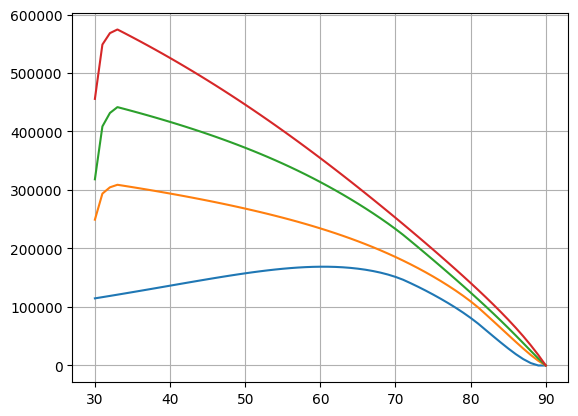

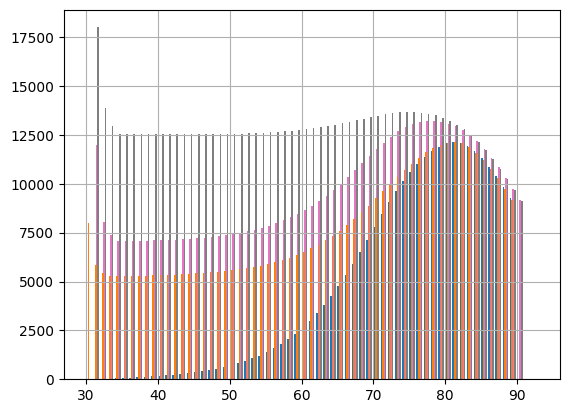

In [5]:
a = Diab2Lifes(PaymentEnd=90)
a.vSetLevelsMort()
a.vSetLevelsDis()
a.vSetLevelsReact()
a.vSetQx(Qx)
a.vSetIx(Ix)
a.vSetRx(Rx)
a.vSetGender(0,1)
a.vSetAges(30,40)
a.vSetBenefits(12000,8000,18000)
a.vPopulatePij()
a.vPopulateApre()
a.vPlot()

for s in Symbols:
    symb1 = s[0]
    symb2 = s[1]
    print("(%s,%s) --> %2d --> Vx=%10.2f"%(symb1,symb2,a.Mapper2Live(symb1,symb2),a.dGetVx(30,symb1,symb2)))


DoShowPij(a, SybTransitions)

**Calculatuion ELE and HLE**

we understand under ELE and HLE the total life expectance and the healthy life expectancy

In [6]:
a.psymM.vSetStartTime(90)
a.iStart=90
a.psymM.vSetStopTime(30)
a.vSetInitState(0)
a.iStop = 30
a.vGenerateTrajectory()
print(a.psymTrajectory[30:])
print(a.psymM.dGetMeanDK(30, 0, 2000000))
print("DONE")

[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  1  2  3  4  4  4  4  4  4  4  4 10 16 22 28 28 28 28 28
 28 28 28 28 28 28 28 28 28 28 28 28  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
114825.51020020437
DONE


In [7]:
print("Note - need to call DK afterwartds, since DK resets via stop / start")

x=30
symb1="S"
symb2="S"
a.psymM.vSetStartTime(90)
a.iStart=90
lTime = x
a.psymM.vSetStopTime(x)
a.iStop = x
iStartState = a.Mapper2Live(symb1,symb2)
a.vSetInitState(iStartState)
nSim =1000000
xVect = np.zeros(nSim)
for i in range(nSim):
    a.vGenerateTrajectory()
    xVect[i] = a.psymM.dGetRandDK(x, 0)
    
    if i<5 or i%100000 ==0:
        print(i,"--->",xVect[i])
        print(a.psymTrajectory[30:])

dk=a.dGetVx(x,symb1,symb2)
strOut ="DK (%s,%s) [%d] = %10.2f (State %d) \n"%(symb1,symb2,x,dk, iStartState)
print(strOut)
strOut += " Mean %10.2f"%np.mean(xVect)
print(strOut)
        
    

Note - need to call DK afterwartds, since DK resets via stop / start
0 ---> 77412.8470060626
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  2  3  4  4  4
  4  4  4 10 16 22 29 29 29 29 29 29  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
1 ---> 81422.78076264018
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  2
  9 16 22 28 28 28 28 28 28 28 28 28  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
2 ---> 122847.75205524094
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  6 12 19 26 27 28 28
 28 28 28 28 28 28 28 28 28 28 29 29  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
3 ---> 131412.7166537478
[ 0  0

 5.00 pct --->   27776.86
10.00 pct --->   44471.44
25.00 pct --->   71738.10
50.00 pct --->  105984.87
75.00 pct --->  146912.10
90.00 pct --->  195140.69
95.00 pct --->  231375.80


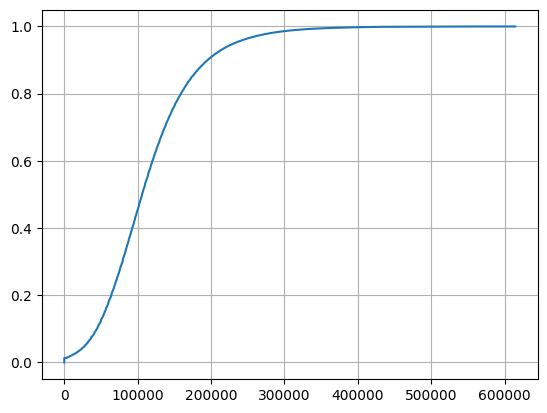

In [8]:
ys = np.sort(xVect)
xs=np.array(range(nSim))/nSim
plt.plot(ys,xs)
plt.grid(True)
quant=[0.05,0.1,0.25,0.5,0.75,0.9,0.95]
for alpha in quant:
    index = int(nSim * alpha + 0.5)
    print("%5.2f pct"%(100*alpha),"--->","%10.2f"%ys[index])

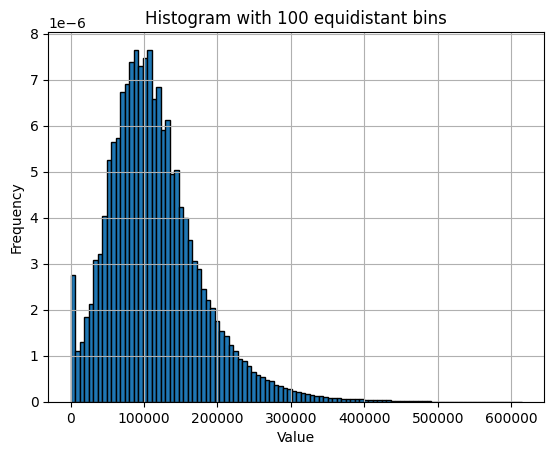

In [10]:
plt.hist(
    xVect,
    bins=100,
    range=(xVect.min(), xVect.max()),
    edgecolor='black', density = True
)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram with 100 equidistant bins")
plt.grid(True)
plt.show()